In [75]:
import pickle
#from functions import data as data_sat
from datetime import datetime, timedelta
import numpy as np
import matplotlib.dates as mdates
import pandas as pd
import copy
import astropy.units as u
import seaborn as sns

import matplotlib.pyplot as plt
from functions import data_test as data

sns.set_style('whitegrid', {'xtick.bottom': False, 'grid.color': 'gainsboro'})
sns.set_context('paper')

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = '#FFC20A' #"xkcd:orange"
c3 = '#0C7BDC' #"xkcd:azure"
c4 = "xkcd:green"

data_path = 'data/'

### Some transformation functions
from https://github.com/ee-davies/sc-data-functions

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import itertools


def cart2sphere(x,y,z):
    r = np.sqrt(x**2+ y**2 + z**2)*u.km.to(u.au)        
    theta = np.arctan2(z,np.sqrt(x**2+ y**2)) * 180. / np.pi
    phi = np.arctan2(y,x) * 180 / np.pi                   
    return (r, theta, phi)


#input datetime to return T1, T2 and T3 based on Hapgood 1992
#http://www.igpp.ucla.edu/public/vassilis/ESS261/Lecture03/Hapgood_sdarticle.pdf
def get_geocentric_transformation_matrices(time):
    #format dates correctly, calculate MJD, T0, UT 
    ts = pd.Timestamp(time)
    jd=ts.to_julian_date()
    mjd=float(int(jd-2400000.5)) #use modified julian date    
    T0=(mjd-51544.5)/36525.0
    UT=ts.hour + ts.minute / 60. + ts.second / 3600. #time in UT in hours    
    #define position of geomagnetic pole in GEO coordinates
    pgeo=78.8+4.283*((mjd-46066)/365.25)*0.01 #in degrees
    lgeo=289.1-1.413*((mjd-46066)/365.25)*0.01 #in degrees
    #GEO vector
    Qg=[np.cos(pgeo*np.pi/180)*np.cos(lgeo*np.pi/180), np.cos(pgeo*np.pi/180)*np.sin(lgeo*np.pi/180), np.sin(pgeo*np.pi/180)]
    #now move to equation at the end of the section, which goes back to equations 2 and 4:
    #CREATE T1; T0, UT is known from above
    zeta=(100.461+36000.770*T0+15.04107*UT)*np.pi/180
    ################### theta und z
    T1=np.matrix([[np.cos(zeta), np.sin(zeta),  0], [-np.sin(zeta) , np.cos(zeta) , 0], [0,  0,  1]]) #angle for transpose
    LAMBDA=280.460+36000.772*T0+0.04107*UT
    M=357.528+35999.050*T0+0.04107*UT
    lt2=(LAMBDA+(1.915-0.0048*T0)*np.sin(M*np.pi/180)+0.020*np.sin(2*M*np.pi/180))*np.pi/180 #lamda sun
    #CREATE T2, LAMBDA, M, lt2 known from above
    ##################### lamdbda und Z
    t2z=np.matrix([[np.cos(lt2), np.sin(lt2),  0], [-np.sin(lt2) , np.cos(lt2) , 0], [0,  0,  1]])
    et2=(23.439-0.013*T0)*np.pi/180
    ###################### epsilon und x
    t2x=np.matrix([[1,0,0],[0,np.cos(et2), np.sin(et2)], [0, -np.sin(et2), np.cos(et2)]])
    T2=np.dot(t2z,t2x)  #equation 4 in Hapgood 1992
    #matrix multiplications   
    T2T1t=np.dot(T2,np.matrix.transpose(T1))
    ################
    Qe=np.dot(T2T1t,Qg) #Q=T2*T1^-1*Qq
    psigsm=np.arctan(Qe.item(1)/Qe.item(2)) #arctan(ye/ze) in between -pi/2 to +pi/2
    T3=np.matrix([[1,0,0],[0,np.cos(-psigsm), np.sin(-psigsm)], [0, -np.sin(-psigsm), np.cos(-psigsm)]])
    return T1, T2, T3


def get_heliocentric_transformation_matrices(time):
    #format dates correctly, calculate MJD, T0, UT 
    ts = pd.Timestamp(time)
    jd=ts.to_julian_date()
    mjd=float(int(jd-2400000.5)) #use modified julian date    
    T0=(mjd-51544.5)/36525.0
    UT=ts.hour + ts.minute / 60. + ts.second / 3600. #time in UT in hours
    #equation 12
    LAMBDA=280.460+36000.772*T0+0.04107*UT
    M=357.528+35999.050*T0+0.04107*UT
    #lamda sun in radians
    lt2=(LAMBDA+(1.915-0.0048*T0)*np.sin(M*np.pi/180)+0.020*np.sin(2*M*np.pi/180))*np.pi/180
    #S1 matrix
    S1=np.matrix([[np.cos(lt2+np.pi), np.sin(lt2+np.pi),  0], [-np.sin(lt2+np.pi) , np.cos(lt2+np.pi) , 0], [0,  0,  1]])
    #equation 13
    #create S2 matrix with angles with reversed sign for transformation HEEQ to HAE
    iota=7.25*np.pi/180
    omega=(73.6667+0.013958*((mjd+3242)/365.25))*np.pi/180 #in rad         
    theta=np.arctan(np.cos(iota)*np.tan(lt2-omega))
    
    #quadrant of theta must be opposite lt2 - omega; Hapgood 1992 end of section 5   
    #get lambda-omega angle in degree mod 360   
    
    lambda_omega_deg=np.mod(lt2-omega,2*np.pi)*180/np.pi
    x = np.cos(np.deg2rad(lambda_omega_deg))
    y = np.sin(np.deg2rad(lambda_omega_deg))
    #get theta_node in deg
    x_theta = np.cos(theta)
    y_theta = np.sin(theta)
    
    ###lambda_omega_deg=np.mod(np.degrees(lt2)-np.degrees(omega),360)
    ###theta_node_deg=np.degrees(theta)
    
       
    #####if the 2 angles are close to similar, so in the same quadrant, then theta_node = theta_node +pi           
    ###if np.logical_or(abs(lambda_omega_deg-theta_node_deg) < 1, abs(lambda_omega_deg-360-theta_node_deg) < 1): theta=theta+np.pi                                                            
        

    ####convert again for array to check    
    ###theta_node_deg=np.degrees(theta)
    
    #if in same quadrant, then theta_node = theta_node +pi  
    if (x>=0 and y>=0):
        if (x_theta>=0 and y_theta>=0): theta = theta - np.pi
        elif (x_theta<=0 and y_theta<=0): theta = theta
        elif (x_theta>=0 and y_theta<=0): theta = theta - np.pi/2
        elif (x_theta<=0 and y_theta>=0): theta = np.pi+(theta-np.pi/2)

    elif (x<=0 and y<=0):
        if (x_theta>=0 and y_theta>=0): theta = theta
        elif (x_theta<=0 and y_theta<=0): theta = theta + np.pi
        elif (x_theta>=0 and y_theta<=0): theta = theta + np.pi/2
        elif (x_theta<=0 and y_theta>=0): theta = theta-np.pi/2

    elif (x>=0 and y<=0):
        if (x_theta>=0 and y_theta>=0): theta = theta + np.pi/2
        elif (x_theta<=0 and y_theta<=0): theta = theta - np.pi/2
        elif (x_theta>=0 and y_theta<=0): theta = theta + np.pi
        elif (x_theta<=0 and y_theta>=0): theta = theta

    elif (x<0 and y>0):
        if (x_theta>=0 and y_theta>=0): theta = theta - np.pi/2
        elif (x_theta<=0 and y_theta<=0): theta = theta + np.pi/2
        elif (x_theta>=0 and y_theta<=0): theta = theta
        elif (x_theta<=0 and y_theta>=0): theta = theta -np.pi    

    s2_theta = np.matrix([[np.cos(theta), np.sin(theta),  0], [-np.sin(theta) , np.cos(theta) , 0], [0,  0,  1]])
    s2_iota = np.matrix([[1,  0,  0], [0, np.cos(iota), np.sin(iota)], [0, -np.sin(iota) , np.cos(iota)]])
    s2_omega = np.matrix([[np.cos(omega), np.sin(omega),  0], [-np.sin(omega) , np.cos(omega) , 0], [0,  0,  1]])
    S2 = np.dot(np.dot(s2_theta,s2_iota),s2_omega)

    return S1, S2


"""
Geocentric position conversions
"""


def GSE_to_GSM(df):
    B_GSM = []
    for i in range(df.shape[0]):
        T1, T2, T3 = get_geocentric_transformation_matrices(df['time'].iloc[i])
        B_GSE_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_GSM_i = np.dot(T3,B_GSE_i)
        B_GSM_i_list = B_GSM_i.tolist()
        flat_B_GSM_i = list(itertools.chain(*B_GSM_i_list))
        r, lat, lon = cart2sphere(flat_B_GSM_i[0], flat_B_GSM_i[1], flat_B_GSM_i[2])
        position = flat_B_GSM_i[0], flat_B_GSM_i[1], flat_B_GSM_i[2], r, lat, lon
        B_GSM.append(position)
    df_transformed = pd.DataFrame(B_GSM, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    df_transformed['time'] = df['time']
    return df_transformed


def GSM_to_GSE(df):
    B_GSE = []
    for i in range(df.shape[0]):
        T1, T2, T3 = get_geocentric_transformation_matrices(df['time'].iloc[i])
        T3_inv = np.linalg.inv(T3)
        B_GSM_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_GSE_i = np.dot(T3_inv,B_GSM_i)
        B_GSE_i_list = B_GSE_i.tolist()
        flat_B_GSE_i = list(itertools.chain(*B_GSE_i_list))
        r, lat, lon = cart2sphere(flat_B_GSE_i[0], flat_B_GSE_i[1], flat_B_GSE_i[2])
        position = flat_B_GSE_i[0], flat_B_GSE_i[1], flat_B_GSE_i[2], r, lat, lon
        B_GSE.append(position)
    df_transformed = pd.DataFrame(B_GSE, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    df_transformed['time'] = df['time']
    return df_transformed


"""
Heliocentric position conversions
"""


def HEE_to_HAE_old(df):
    B_HAE = []
    for i in range(df.shape[0]):
        S1, S2 = get_heliocentric_transformation_matrices(df['time'].iloc[i])
        S1_inv = np.linalg.inv(S1)
        B_HEE_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_HEA_i = np.dot(S1_inv,B_HEE_i)
        B_HAE_i_list = B_HEA_i.tolist()
        flat_B_HAE_i = list(itertools.chain(*B_HAE_i_list))
        r, lat, lon = cart2sphere(flat_B_HAE_i[0], flat_B_HAE_i[1], flat_B_HAE_i[2])
        position = flat_B_HAE_i[0], flat_B_HAE_i[1], flat_B_HAE_i[2], r, lat, lon
        B_HAE.append(position)
    df_transformed = pd.DataFrame(B_HAE, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    # df_transformed['time'] = df['time']
    return df_transformed


def HEE_to_HAE(df):
    timeseries = df.time
    HEE = np.vstack((df.x, df.y, df.z)).T
    transformation_matrices = np.array([np.linalg.inv(get_heliocentric_transformation_matrices(t)[0]) for t in timeseries])
    HAE = np.einsum('ijk,ik->ij', transformation_matrices, HEE)
    r, lat, lon = cart2sphere(HAE[:,0],HAE[:,1],HAE[:,2])
    df_transformed = pd.concat([timeseries], axis=1)
    df_transformed['x'] = HAE[:,0]
    df_transformed['y'] = HAE[:,1]
    df_transformed['z'] = HAE[:,2]
    df_transformed['r'] = r
    df_transformed['lat'] = lat
    df_transformed['lon'] = lon
    return df_transformed


def HAE_to_HEE(df):
    B_HEE = []
    for i in range(df.shape[0]):
        S1, S2 = get_heliocentric_transformation_matrices(df['time'].iloc[i])
        B_HAE_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_HEE_i = np.dot(S1,B_HAE_i)
        B_HEE_i_list = B_HEE_i.tolist()
        flat_B_HEE_i = list(itertools.chain(*B_HEE_i_list))
        r, lat, lon = cart2sphere(flat_B_HEE_i[0], flat_B_HEE_i[1], flat_B_HEE_i[2])
        position = flat_B_HEE_i[0], flat_B_HEE_i[1], flat_B_HEE_i[2], r, lat, lon
        B_HEE.append(position)
    df_transformed = pd.DataFrame(B_HEE, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    df_transformed['time'] = df['time']
    return df_transformed


def HAE_to_HEEQ_old(df):
    B_HEEQ = []
    for i in range(df.shape[0]):
        S1, S2 = get_heliocentric_transformation_matrices(df['time'].iloc[i])
        B_HAE_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_HEEQ_i = np.dot(S2,B_HAE_i)
        B_HEEQ_i_list = B_HEEQ_i.tolist()
        flat_B_HEEQ_i = list(itertools.chain(*B_HEEQ_i_list))
        r, lat, lon = cart2sphere(flat_B_HEEQ_i[0], flat_B_HEEQ_i[1], flat_B_HEEQ_i[2])
        position = flat_B_HEEQ_i[0], flat_B_HEEQ_i[1], flat_B_HEEQ_i[2], r, lat, lon
        B_HEEQ.append(position)
    df_transformed = pd.DataFrame(B_HEEQ, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    # df_transformed['time'] = df['time']
    return df_transformed


def HAE_to_HEEQ(df):
    timeseries = df.time
    HAE = np.vstack((df.x, df.y, df.z)).T
    transformation_matrices = np.array([get_heliocentric_transformation_matrices(t)[1] for t in timeseries])
    HEEQ = np.einsum('ijk,ik->ij', transformation_matrices, HAE)
    r, lat, lon = cart2sphere(HEEQ[:,0],HEEQ[:,1],HEEQ[:,2])
    df_transformed = pd.concat([timeseries], axis=1)
    df_transformed['x'] = HEEQ[:,0]
    df_transformed['y'] = HEEQ[:,1]
    df_transformed['z'] = HEEQ[:,2]
    df_transformed['r'] = r
    df_transformed['lat'] = lat
    df_transformed['lon'] = lon
    return df_transformed


def HEEQ_to_HAE(df):
    B_HAE = []
    for i in range(df.shape[0]):
        S1, S2 = get_heliocentric_transformation_matrices(df['time'].iloc[i])
        S2_inv = np.linalg.inv(S2)
        B_HEEQ_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_HAE_i = np.dot(S2_inv, B_HEEQ_i)
        B_HAE_i_list = B_HAE_i.tolist()
        flat_B_HAE_i = list(itertools.chain(*B_HAE_i_list))
        r, lat, lon = cart2sphere(flat_B_HAE_i[0], flat_B_HAE_i[1], flat_B_HAE_i[2])
        position = flat_B_HAE_i[0], flat_B_HAE_i[1], flat_B_HAE_i[2], r, lat, lon
        B_HAE.append(position)
    df_transformed = pd.DataFrame(B_HAE, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    df_transformed['time'] = df['time']
    return df_transformed


def HEE_to_HEEQ(df):
    df_hae = HEE_to_HAE(df)
    df_transformed = HAE_to_HEEQ(df_hae)
    return df_transformed


def HEEQ_to_HEE(df):
    df_hae = HEEQ_to_HAE(df)
    df_transformed = HAE_to_HEE(df_hae)
    return df_transformed


"""
Geocentric to heliocentric position conversions
#requires extra step in the conversion of GSE to HEE i.e. adding position vector of Sun
"""

def get_rsun_position_vector(time):
    #format dates correctly, calculate MJD, T0, UT 
    ts = pd.Timestamp(time)
    jd=ts.to_julian_date()
    mjd=float(int(jd-2400000.5)) #use modified julian date    
    T0=(mjd-51544.5)/36525.0
    UT=ts.hour + ts.minute / 60. + ts.second / 3600. #time in UT in hours
    LAMBDA=280.460+36000.772*T0+0.04107*UT
    M=357.528+35999.050*T0+0.04107*UT
    lt2=(LAMBDA+(1.915-0.0048*T0)*np.sin(M*np.pi/180)+0.020*np.sin(2*M*np.pi/180))*np.pi/180. #lamda sun
    #section 6.1
    r_0 = 1.495985E8 #units km
    e = 0.016709 - 0.0000418*T0
    omega_bar = (282.94 + 1.72*T0)*np.pi/180.
    v = lt2 - omega_bar
    #final r_sun equation
    r_sun = (r_0*(1 - e**2)) / (1 + e*np.cos(v))
    R_sun = np.matrix([[r_sun],[0],[0]])
    return R_sun


def get_rsun_position(time):
    #format dates correctly, calculate MJD, T0, UT 
    ts = pd.Timestamp(time)
    jd=ts.to_julian_date()
    mjd=float(int(jd-2400000.5)) #use modified julian date    
    T0=(mjd-51544.5)/36525.0
    UT=ts.hour + ts.minute / 60. + ts.second / 3600. #time in UT in hours
    LAMBDA=280.460+36000.772*T0+0.04107*UT
    M=357.528+35999.050*T0+0.04107*UT
    lt2=(LAMBDA+(1.915-0.0048*T0)*np.sin(M*np.pi/180)+0.020*np.sin(2*M*np.pi/180))*np.pi/180. #lamda sun
    #section 6.1
    r_0 = 1.495985E8 #units km
    e = 0.016709 - 0.0000418*T0
    omega_bar = (282.94 + 1.72*T0)*np.pi/180.
    v = lt2 - omega_bar
    #final r_sun equation
    r_sun = (r_0*(1 - e**2)) / (1 + e*np.cos(v))
    return r_sun


def GSE_to_HEE_old(df):
    B_HEE = []
    z_rot_180 = np.matrix([[-1, 0, 0],[0, -1, 0],[0, 0, 1]])
    for i in range(df.shape[0]):
        R_sun = get_rsun_position_vector(df['time'].iloc[i])
        B_GSE_i = np.matrix([[df['x'].iloc[i]],[df['y'].iloc[i]],[df['z'].iloc[i]]]) 
        B_HEE_i = R_sun + np.dot(z_rot_180,B_GSE_i)
        B_HEE_i_list = B_HEE_i.tolist()
        flat_B_HEE_i = list(itertools.chain(*B_HEE_i_list))
        r, lat, lon = cart2sphere(flat_B_HEE_i[0], flat_B_HEE_i[1], flat_B_HEE_i[2])
        position = flat_B_HEE_i[0], flat_B_HEE_i[1], flat_B_HEE_i[2], r, lat, lon
        B_HEE.append(position)
    df_transformed = pd.DataFrame(B_HEE, columns=['x', 'y', 'z', 'r', 'lat', 'lon'])
    #df time replication no longer works
    return df_transformed


def GSE_to_HEE(df):
    timeseries = df.time
    r_suns = []
    for t in timeseries:
        r_sun = get_rsun_position(t)
        r_suns.append(r_sun)
    x = -df.x + r_suns
    y = -df.y
    z = df.z
    r, lat, lon = cart2sphere(x,y,z)
    df_transformed = pd.concat([timeseries, x, y, z], axis=1)
    df_transformed['r'] = r
    df_transformed['lat'] = lat
    df_transformed['lon'] = lon
    return df_transformed


def HEE_to_GSE(df):
    timeseries = df.time
    r_suns = []
    for t in timeseries:
        r_sun = get_rsun_position(t)
        r_suns.append(r_sun)
    x = r_suns - df.x
    y = -df.y
    z = df.z
    r, lat, lon = cart2sphere(x,y,z)
    df_transformed = pd.concat([timeseries, x, y, z], axis=1)
    df_transformed['r'] = r
    df_transformed['lat'] = lat
    df_transformed['lon'] = lon
    return df_transformed

# to print transformation matrices: S1, S2 = get_heliocentric_transformation_matrices(datetime(2022,11,11,0,0,0))

### L1 real-time data preparation

1. load data, cut to time range Nov 2022 - June 2024
2. convert positions from HEEQ to GSE coordinates for time shifting to Earth

In [3]:
def interp_to_grid_l1(sc_in):
    sc_input1 = copy.deepcopy(sc_in)
    
    t_start=datetime(2022,11,11,0,0)
    t_end=datetime(2024,6,5,0,0)

    t1=sc_input1.time

    time_all = [ t_start + timedelta(minutes=1*n) for n in range(int ((t_end - t_start).days*60*24)+1)]  
    time_mat=mdates.date2num(time_all) 

    sc_input=np.zeros(np.size(time_all),dtype=[('time',object),('sc', float),\
            ('bx', float),('by', float),('bz', float),('bt', float),\
            ('r', float),('lat', float),('lon', float),\
            ('x', float),('y', float),('z', float),('vx', float),\
            ('vy', float),('vz', float),('vt', float),('tp', float),('np', float) ] ) 

    sc_input =sc_input.view(np.recarray)  

    time_m_num=mdates.date2num(t1) #make date number

    sc_input.time=time_all
    sc_input.sc=np.interp(time_mat, time_m_num, sc_input1.source_mag)
    sc_input.x=np.interp(time_mat, time_m_num, sc_input1.x)
    sc_input.y=np.interp(time_mat, time_m_num, sc_input1.y)
    sc_input.z=np.interp(time_mat, time_m_num, sc_input1.z)
    
    sc_input.np=np.interp(time_mat, time_m_num, sc_input1.np)
    sc_input.tp=np.interp(time_mat, time_m_num, sc_input1.tp) 
    sc_input.vt=np.interp(time_mat, time_m_num, sc_input1.vt)

    sc_input.bx=np.interp(time_mat, time_m_num, sc_input1.bx)
    sc_input.by=np.interp(time_mat, time_m_num, sc_input1.by)
    sc_input.bz=np.interp(time_mat, time_m_num, sc_input1.bz)
    sc_input.bt=np.interp(time_mat, time_m_num, sc_input1.bt)
    
    sc_input.r=np.interp(time_mat, time_m_num, sc_input1.r)
    sc_input.lon=np.interp(time_mat, time_m_num, sc_input1.lon)
    sc_input.lat=np.interp(time_mat, time_m_num, sc_input1.lat)
    
    print(sc_input.time[0], sc_input.time[-1])
    return sc_input


In [5]:
l1_heeq = pickle.load(open(data_path+'noaa_archive_gsm.p', 'rb'))
earth_pos = pickle.load(open(data_path+'earth_pos_HEEQ_20221111_20240604.p', 'rb'))

In [6]:
l1_interp_new = interp_to_grid_l1(l1_heeq)

2022-11-11 00:00:00 2024-06-05 00:00:00


In [7]:
#print(l1_heeq.source_plasma)
l1_ace = l1_heeq[l1_heeq.source_mag == 0]
l1_dscovr = l1_heeq[l1_heeq.source_mag == 1]

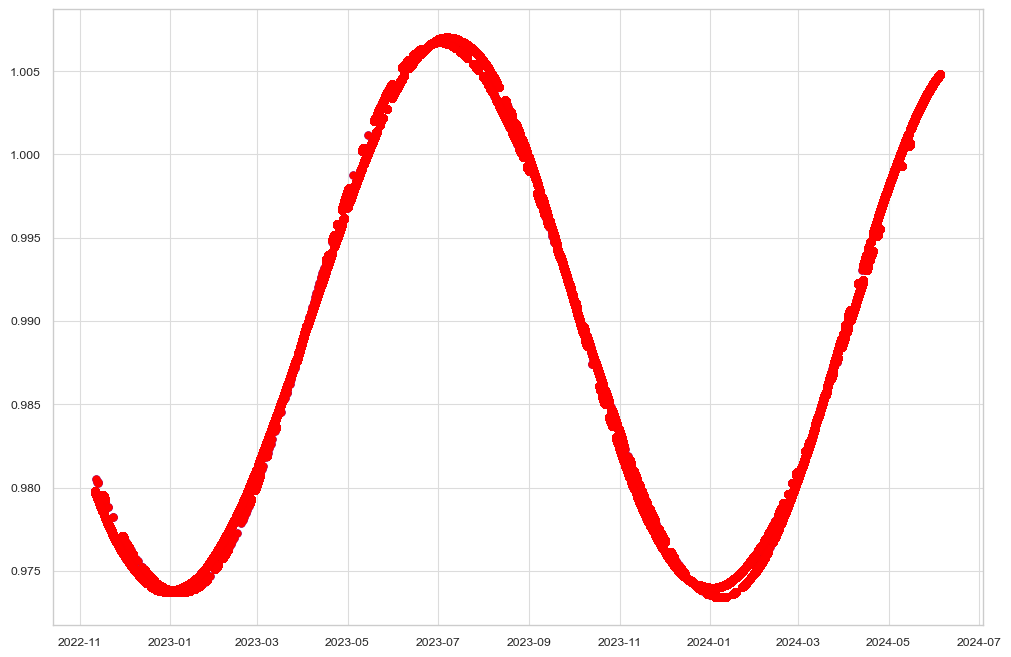

In [8]:
plt.figure(figsize=(12,8))
plt.plot(l1_heeq.time, l1_heeq.r, 'bo', ms=5)
plt.plot(l1_heeq.time, l1_heeq.r, 'ro', ms=5)

In [9]:
t_start=datetime(2022,11,11,0,0)
t_end=datetime(2024,6,5,0,0)

time_all = [ t_start + timedelta(minutes=1*n) for n in range(int ((t_end - t_start).days*60*24)+1)] 

r_sun_pos = []

for i in time_all:
    r_sun = get_rsun_position(i)
    r_sun_pos.append(r_sun)

In [11]:
l1_pos_interp = interp_to_grid_l1(l1_heeq)

2022-11-11 00:00:00 2024-06-05 00:00:00


In [12]:
l1_pos = copy.deepcopy(l1_pos_interp)

l1_pos.sc[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
l1_pos.x[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
l1_pos.y[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
l1_pos.z[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
l1_pos.r[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
l1_pos.lon[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
l1_pos.lat[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.vt[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.np[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.tp[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.bt[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.bx[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.by[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan
#l1_pos.bz[(l1_pos.sc!=1.) & (l1_pos.sc!=0.)] = np.nan

In [13]:
l1_df = pd.DataFrame(l1_pos[['time', 'x', 'y', 'z']].copy())

#print(l1_df) #check if x,y,z are given in km or au#

l1_hee = HEEQ_to_HEE(l1_df)
l1_gse = HEE_to_GSE(l1_hee)

In [14]:
l1_fin =  copy.deepcopy(l1_pos)

l1_fin.x = l1_gse.x
l1_fin.y = l1_gse.y
l1_fin.z = l1_gse.z
l1_fin.r = l1_gse.r
l1_fin.lon = l1_gse.lon
l1_fin.lat = l1_gse.lat

In [32]:
#save file

#pickle.dump(l1_fin, open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE_corr.p', 'wb'))
#l1_fin = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE_corr.p', 'rb'))

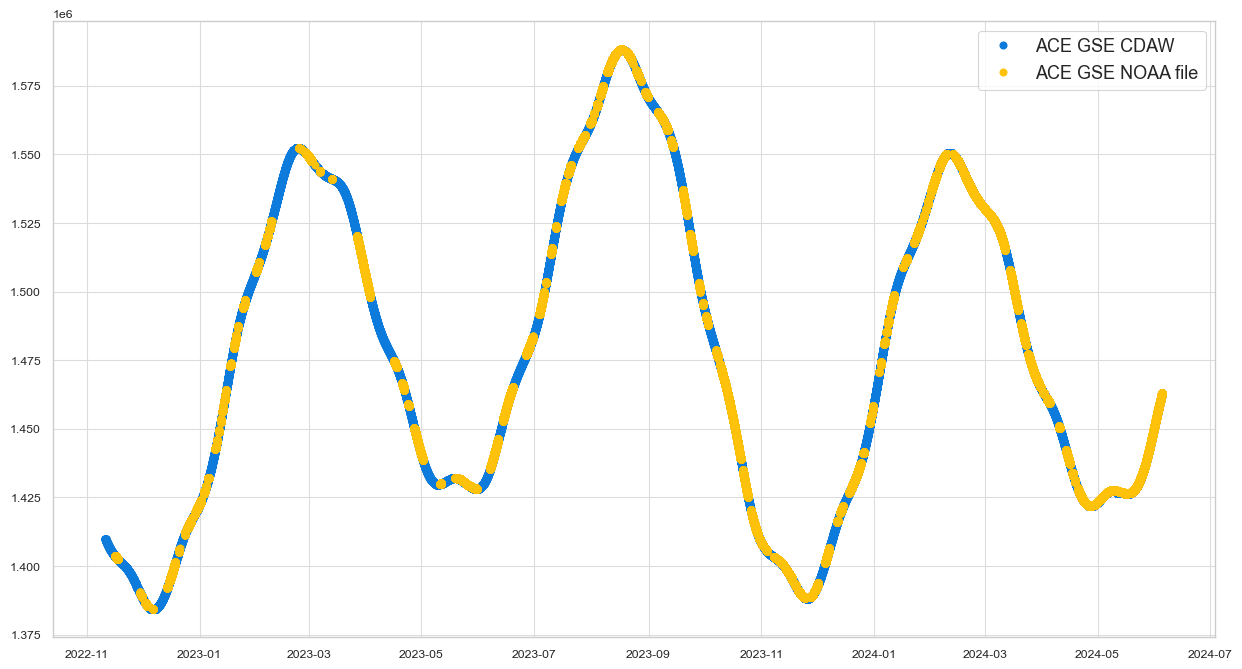

In [16]:
#Plot ACE positions from CDAW and transformed NOAA HEEQ data to see if they agree

#ace_pos_gse = pd.read_csv(data_path+'ACE_pos_GSE.csv', delimiter=',', comment='#', names=['time', 'lat', 'lon', 'r_earth', 'x', 'y', 'z', 'x1', 'y1', 'z1'])
#ace_pos_gse['time'] = pd.to_datetime(ace_pos_gse['time'])


plt.figure(figsize=(15,8))
#plt.plot(ace_pos_gse.time, ace_pos_gse.x, color=c3, marker='o', ls=' ', label='ACE GSE CDAW')
plt.plot(l1_fin[l1_fin.sc==0].time, l1_fin.x[l1_fin.sc==0], color=c2, marker='o', ls=' ', label='ACE GSE NOAA file')
plt.legend(fontsize=13)

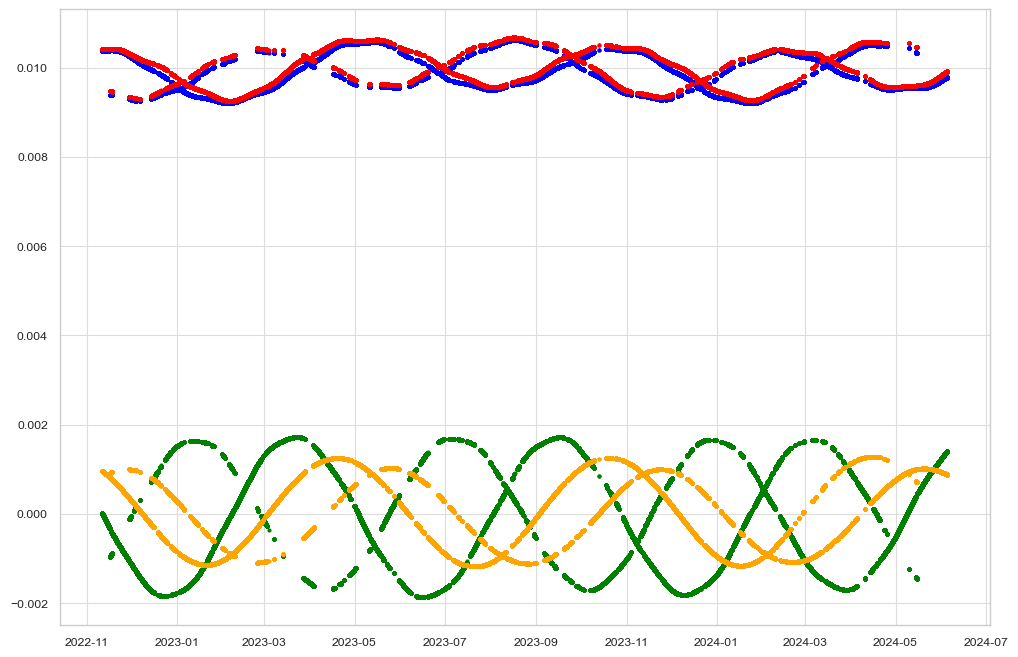

In [17]:
#positions look like that because sometimes ACE sometimes DSCOVR used in NOAA RTSW data product:

plt.figure(1, figsize=(12,8))
plt.plot(l1_fin.time, l1_fin.x*u.km.to(u.au), 'bo', ms=2, ls='')
plt.plot(l1_fin.time, l1_fin.y*u.km.to(u.au), 'go', ms=2, ls='')
plt.plot(l1_fin.time, l1_fin.z*u.km.to(u.au), color = 'orange', marker='o', ms=2, ls='')
plt.plot(l1_fin.time, l1_fin.r, 'ro', ms=2, ls='')

#plt.figure(2, figsize=(12,8))
#plt.plot(l1_fin.time, l1_fin.r, 'ro', ms=2)

#plt.plot(l1_gsm.time, l1_gsm.lon)
#plt.plot(l1_gsm.time, l1_gsm.lat)

In [34]:
#pickle.dump(l1_heeq, open(data_path+'noaa_20221111_20240604_B_GSM_Coords_HEEQ_corr.p', 'wb'))

In [10]:
#l1_pos = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_HEEQ_corr.p', 'rb'))
#l1_input_in = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE_corr.p', 'rb'))


### STEREO-A science data preparation

1. load data, cut to time range that is investigated 
2. convert coordinates given in HEEQ to GSE for time shift 
3. convert magnetic field data to GSM for TL model

In [76]:
def interp_nans(sc_in, single=False):
    sc = copy.deepcopy(sc_in)
    
    n = len(sc)

    # Use index positions as the x-axis (since time steps are regular)
    x = np.arange(n)
    
    if single:
        mask = ~np.isnan(sc)
        
        if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
            # Interpolate over valid points
            sc = np.interp(x, x[mask], sc[mask])
        else:
            print(f"Skipping '{key}': not enough valid data to interpolate.")
            
    else:
        keys_to_interp = [name for name in sc.dtype.names if name != 'time']

        for key in keys_to_interp:
            y = sc[key]

            if y.dtype.kind in 'f':  # Only interpolate float fields
                mask = ~np.isnan(y)

                if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
                    # Interpolate over valid points
                    sc[key] = np.interp(x, x[mask], y[mask])
                else:
                    print(f"Skipping '{key}': not enough valid data to interpolate.")

                
    return sc

In [77]:
[sc_input_sci, header] = pickle.load(open(data_path+'stereoa_2007_now_rtn.p', 'rb'))
sc_input_sci = sc_input_sci[(sc_input_sci.time>=datetime(2022,11,11)) & (sc_input_sci.time<=datetime(2024,6,5))]     

#l1_pos = interp_nans(l1_heeq)
#print(sc_input_sci.x)

In [78]:
earth_pos = pickle.load(open(data_path+'earth_pos_HEEQ_20221111_20240604.p', 'rb'))

-1.2514875153550884


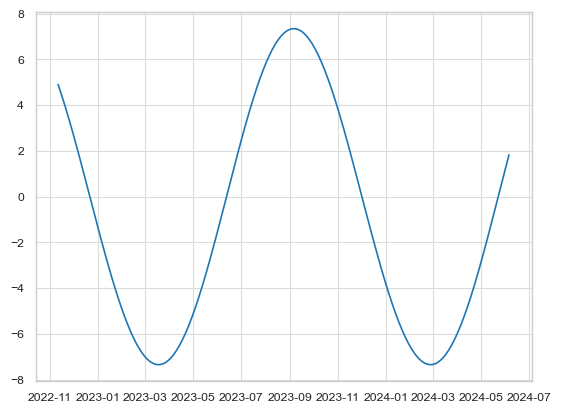

In [79]:
print(np.nanmean(sc_input_sci.lat))
plt.plot(sc_input_sci.time, sc_input_sci.lat)

In [80]:
load_sta = True

def interp_to_grid(sc_in):
    sc_input1 = copy.deepcopy(sc_in)
    
    t_start=datetime(2022,11,11,0,0)
    t_end=datetime(2024,6,5,0,0)

    t1=sc_input1.time

    time_all = [ t_start + timedelta(minutes=1*n) for n in range(int ((t_end - t_start).days*60*24)+1)]  
    time_mat=mdates.date2num(time_all) 

    sc_input=np.zeros(np.size(time_all),dtype=[('time',object),('bx', float),('by', float),\
            ('bz', float),('bt', float),('r', float),('lat', float),('lon', float),\
            ('x', float),('y', float),('z', float),('vx', float),\
            ('vy', float),('vz', float),('vt', float),('tp', float),('np', float) ] ) 

    sc_input =sc_input.view(np.recarray)  

    time_m_num=mdates.date2num(t1) #make date number

    sc_input.time=time_all

    sc_input.np=np.interp(time_mat, time_m_num, sc_input1.np)
    sc_input.tp=np.interp(time_mat, time_m_num, sc_input1.tp) 
    sc_input.vt=np.interp(time_mat, time_m_num, sc_input1.vt)

    sc_input.bx=np.interp(time_mat, time_m_num, sc_input1.bx)
    sc_input.by=np.interp(time_mat, time_m_num, sc_input1.by)
    sc_input.bz=np.interp(time_mat, time_m_num, sc_input1.bz)
    sc_input.bt=np.interp(time_mat, time_m_num, sc_input1.bt)
    
    sc_input.x=np.interp(time_mat, time_m_num, sc_input1.x)
    sc_input.y=np.interp(time_mat, time_m_num, sc_input1.y)
    sc_input.z=np.interp(time_mat, time_m_num, sc_input1.z)
    
    sc_input.r=np.interp(time_mat, time_m_num, sc_input1.r)
    sc_input.lon=np.interp(time_mat, time_m_num, sc_input1.lon)
    sc_input.lat=np.interp(time_mat, time_m_num, sc_input1.lat)
    
    print(sc_input.time[0], sc_input.time[-1])
    return sc_input

In [81]:
sc_input = interp_to_grid(sc_input_sci)

2022-11-11 00:00:00 2024-06-05 00:00:00


In [57]:
pickle.dump(sc_input, open(data_path+'sta_science_HEEQ_20221111_20240604.p', 'wb'))

In [82]:
sc_mag_gse = data.convert_RTN_to_GSE_sta_l1(sc_input)
sc_mag_gsm = data.convert_GSE_to_GSM_new(sc_mag_gse)

conversion RTN to GSE
conversion RTN to GSE done
conversion GSE to GSM
conversion GSE to GSM done


In [58]:
delta_r = l1_pos.r-sc_input.r

index_min = np.where((l1_pos.r-sc_input.r)==np.nanmin(l1_pos.r-sc_input.r))[0][0]
index_max = np.where((l1_pos.r-sc_input.r)==np.nanmax(l1_pos.r-sc_input.r))[0][0]

index_min_earth = np.where((earth_pos.r-sc_input.r)==np.nanmin(earth_pos.r-sc_input.r))[0][0]
index_max_earth = np.where((earth_pos.r-sc_input.r)==np.nanmax(earth_pos.r-sc_input.r))[0][0]

time_min=sc_input.time[index_min]
time_max=sc_input.time[index_max]

time_min_earth=sc_input.time[index_min_earth]
time_max_earth=sc_input.time[index_max_earth]
print(time_min, time_max)
print(time_min_earth, time_max_earth)

delta_r_earth = earth_pos.r-sc_input.r

delta_r_earth_min = delta_r_earth[index_min_earth]
delta_r_earth_max = delta_r_earth[index_max_earth]
print(delta_r_earth_max)

#print(earth_pos.time[delta_r_earth>=0.05][156200:156250])

2024-01-06 21:15:00 2024-06-05 00:00:00
2024-01-02 07:16:00 2024-06-05 00:00:00
0.05979723592916286


(-15.089907820285756, 14.933696518659557)

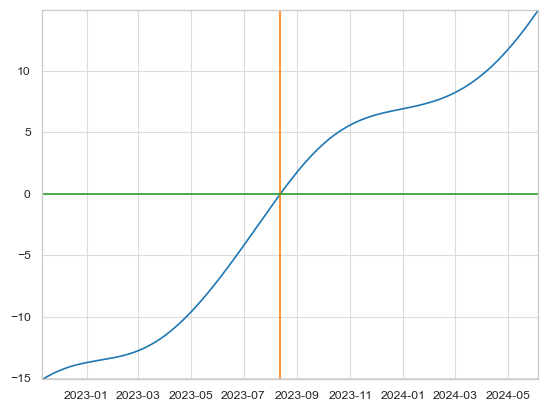

In [25]:
plt.plot(sc_input.time, sc_input.lon)
plt.plot([sc_input.time[sc_input.time==datetime(2023,8,12)],sc_input.time[sc_input.time==datetime(2023,8,12)]], [-15,15])
plt.plot([sc_input.time[0],sc_input.time[-1]], [0,0])
plt.xlim(sc_input.time[0], sc_input.time[-1])
plt.ylim(sc_input.lon[0], sc_input.lon[-1])



### Create Figure 1 in paper

0.06 0.02


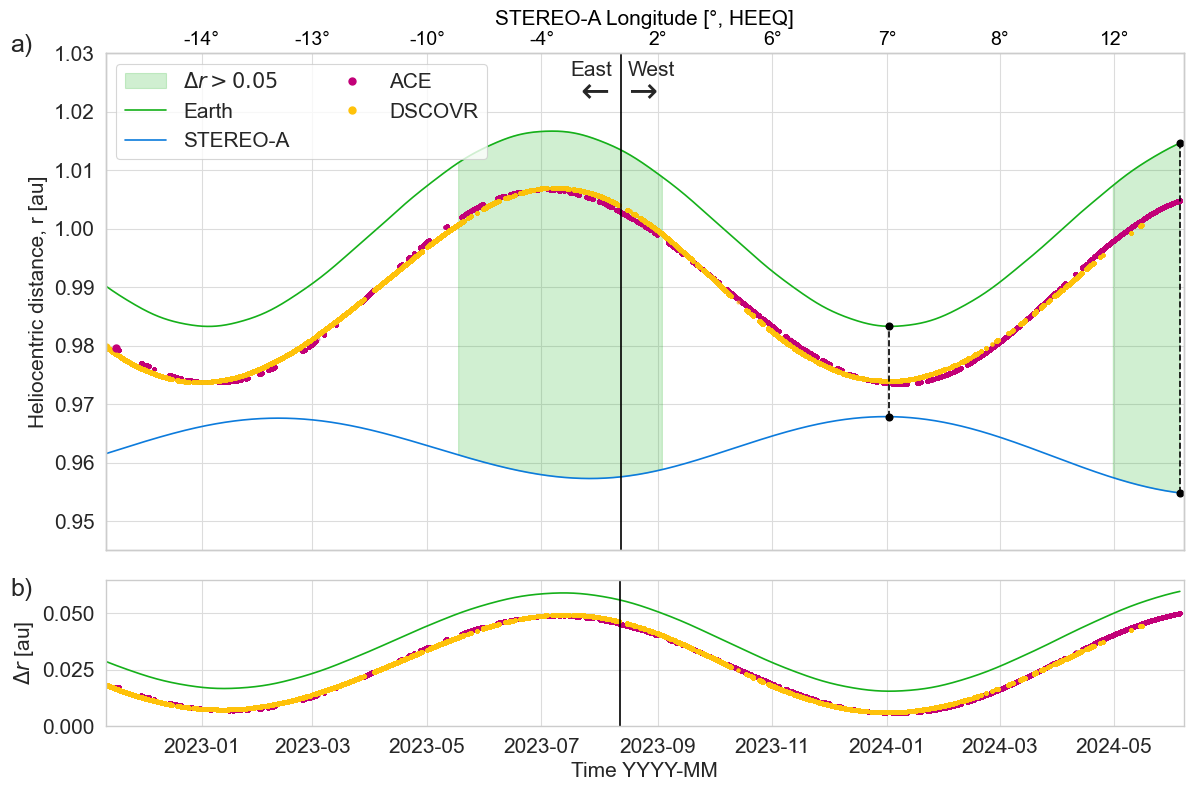

In [84]:
#import matplotlib.ticker as ticker

fig = plt.figure(figsize=(12,8), dpi=100)

ax3 = plt.subplot2grid((4,1), (0, 0), rowspan=3)

ax3.fill_between(sc_input.time, sc_input.r, earth_pos.r, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')
ax3.plot(earth_pos.time, earth_pos.r, color=c4, label='Earth')
ax3.plot(l1_ace.time, l1_ace.r, color=c1, marker='o', ms=2, ls='', alpha=0.3)
ax3.plot(l1_dscovr.time, l1_dscovr.r, color=c2, marker='o', ms=2, ls='', alpha=0.3)
ax3.plot(sc_input.time, sc_input.r, color=c3, label='STEREO-A')
ax3.plot(l1_ace.time[0], l1_ace.r[0], color=c1, marker='o', ms=5, ls='', label='ACE')
ax3.plot(l1_dscovr.time[0], l1_dscovr.r[0], color=c2, marker='o', ms=5, ls='', label='DSCOVR')
ax3.plot_date([time_min_earth,time_min_earth], [sc_input.r[index_min_earth],earth_pos.r[index_min_earth]], linestyle='--', color=c0)
ax3.plot_date([time_max_earth,time_max_earth], [sc_input.r[index_max_earth],earth_pos.r[index_max_earth]], linestyle='--', color=c0)
#ax3.plot_date([time_min,time_min], [sc_input.r[index_min],l1_pos.r[index_min]], linestyle='--', color=c0)
#ax3.plot_date([time_max,time_max], [sc_input.r[index_max],l1_pos.r[index_max]], linestyle='--', color=c0)
ax3.plot([datetime(2023,8,12,12,10),datetime(2023,8,12,12,10)], [-2,2], 'k-')
ax3.set_ylim(0.945,1.03)
#ax1.set_xlabel('time YYYY-MM',fontsize=13)
ax3.legend(loc='upper left', ncol=2, fontsize=15)
ax3.set_xlim(sc_input.time[0],sc_input.time[-1]+timedelta(days=2))
ax3.tick_params(axis='x', labelbottom='off', length=0)
ax3.set_xticklabels([])
ax3.tick_params(axis='y', labelsize=15)
ax3.set_ylabel('Heliocentric distance, r [au]',fontsize=15)
ax2 = ax3.twiny()
ticks = ax3.get_xticks()
ax2.set_xticks(mdates.num2date(ticks))
ax2.grid(False)
t_float=mdates.date2num(sc_input.time)
lon_interp = np.interp(ticks, t_float, sc_input.lon)
ax2.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=14)
ax2.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=15)  # we already handled the x-label with ax1
ax2.tick_params(axis='x', length=0)
ax2.set_xlim(ax3.get_xlim())


ax4 = plt.subplot2grid((4,1), (3, 0), rowspan=1)
ax4.plot(earth_pos.time, delta_r_earth, color=c4)
ax4.plot(l1_pos.time[l1_pos.sc == 0], delta_r[l1_pos.sc == 0], marker='o', ms=2, ls='', color=c1)
ax4.plot(l1_pos.time[l1_pos.sc == 1], delta_r[l1_pos.sc == 1], marker='o', ms=2, ls='', color=c2)
ax4.plot([datetime(2023,8,12),datetime(2023,8,12)], [0,0.07], 'k-')
ax4.tick_params(axis='x', labelsize=15)
ax4.tick_params(axis='y', labelsize=15)
ax4.set_ylabel(r'$\Delta r$ [au]',fontsize=15)
ax4.set_xlabel('Time YYYY-MM',fontsize=15)
#ax2.legend(fontsize=13)
ax4.set_xlim(sc_input.time[0],sc_input.time[-1]+timedelta(days=2))
ax4.set_ylim(0.0,0.065)

plt.figtext(0.01,0.93, 'a)', fontsize=18)
plt.figtext(0.01,0.25, 'b)', fontsize=18)
plt.figtext(0.477,0.9, 'East', fontsize=15)
plt.figtext(0.525,0.9, 'West', fontsize=15)
plt.figtext(0.48,0.87, r'$\leftarrow$', fontsize=25)
plt.figtext(0.52,0.87, r'$\rightarrow$', fontsize=25)

plt.tight_layout()
fig.subplots_adjust(hspace=0.2)

#plt.savefig('l1_sta_earth_pos.png')

print(round(np.nanmax(earth_pos.r-sc_input.r),2), round(np.nanmin(earth_pos.r-sc_input.r),2))

In [85]:
sta_df = pd.DataFrame(sc_mag_gsm[['time', 'x', 'y', 'z']].copy())
#sta_df.x = sc_input_sci.x#*u.au.to(u.km)
#sta_df.y = sc_input_sci.y#*u.au.to(u.km)
#sta_df.z = sc_input_sci.z#*u.au.to(u.km)

#print(sta_df.x) #check if x,y,z are given in km or au

sta_hee = HEEQ_to_HEE(sta_df)
sta_gse = HEE_to_GSE(sta_hee)

In [86]:
sta_fin =  copy.deepcopy(sc_input)

sta_fin.x = sta_gse.x
sta_fin.y = sta_gse.y
sta_fin.z = sta_gse.z
sta_fin.r = sta_gse.r
sta_fin.lon = sta_gse.lon
sta_fin.lat = sta_gse.lat

Text(0.5, 1.0, 'GSE Lat')

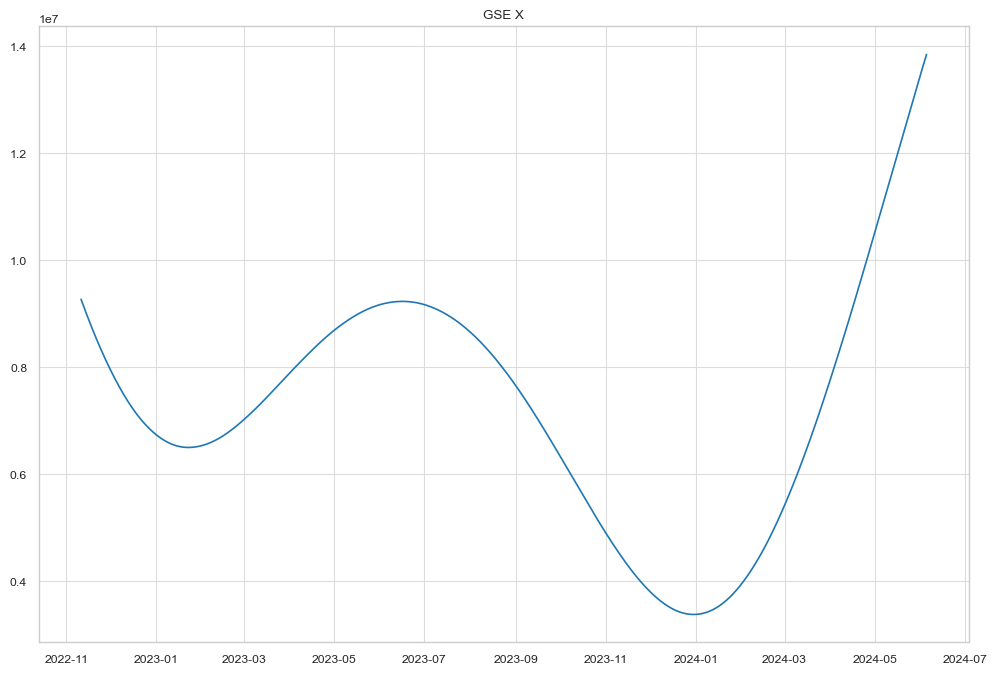

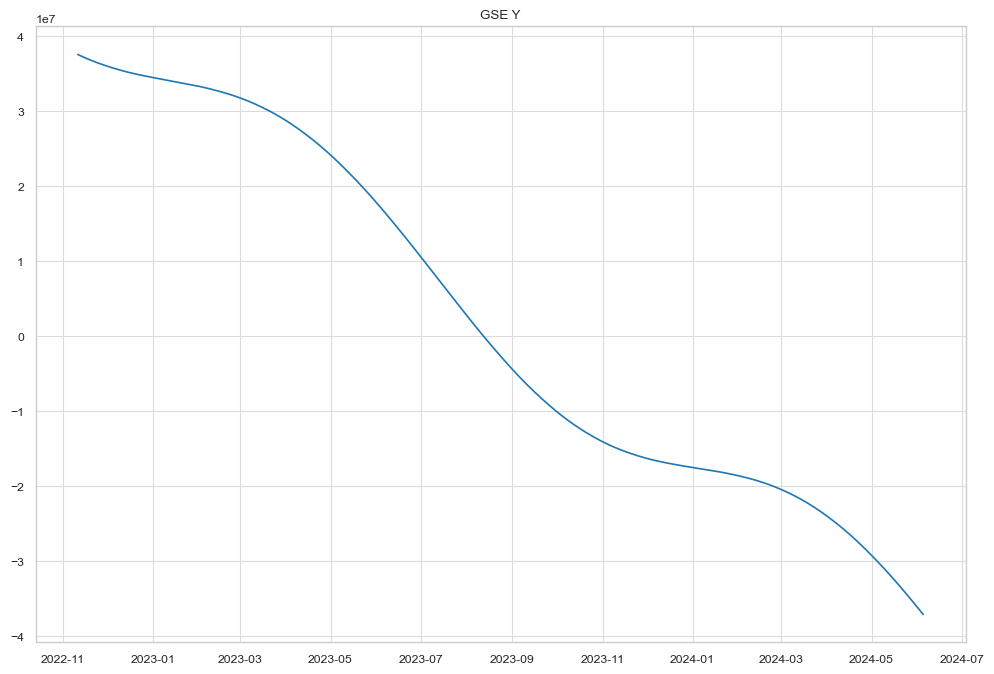

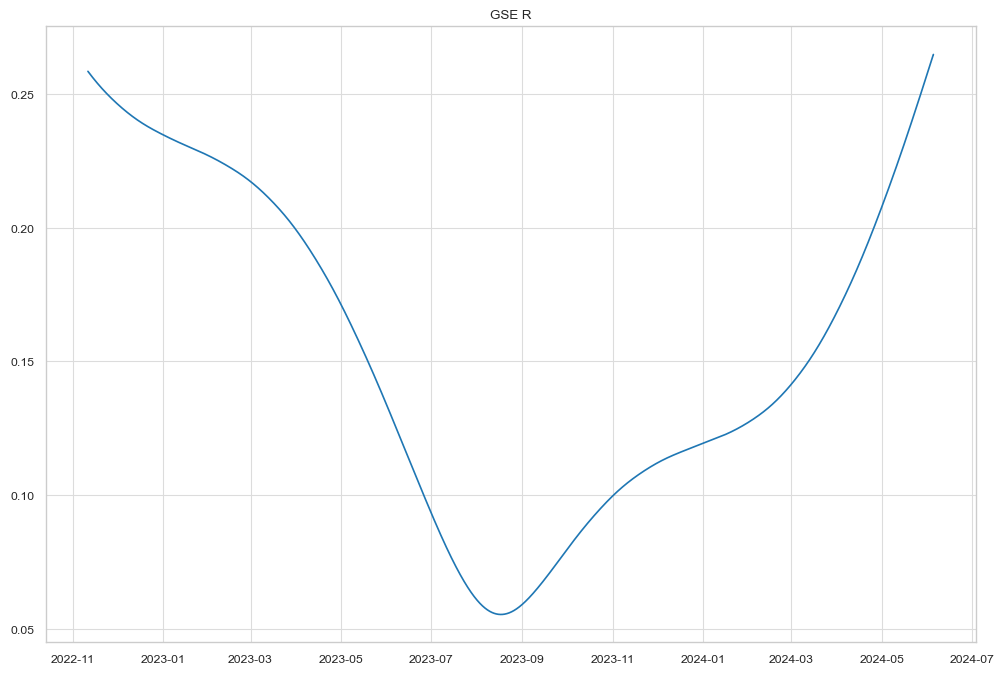

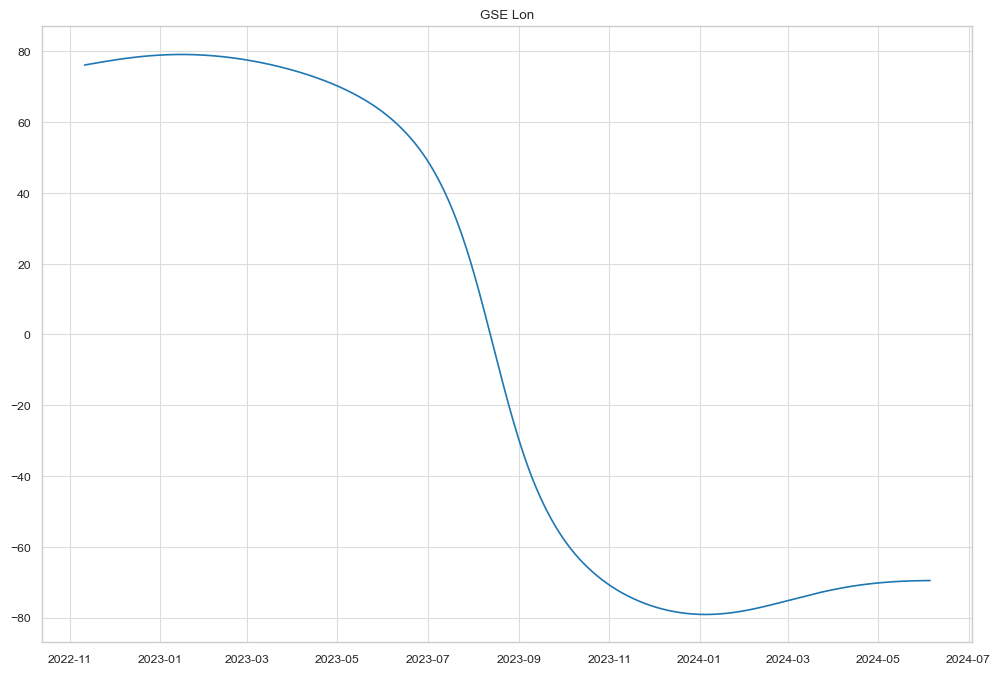

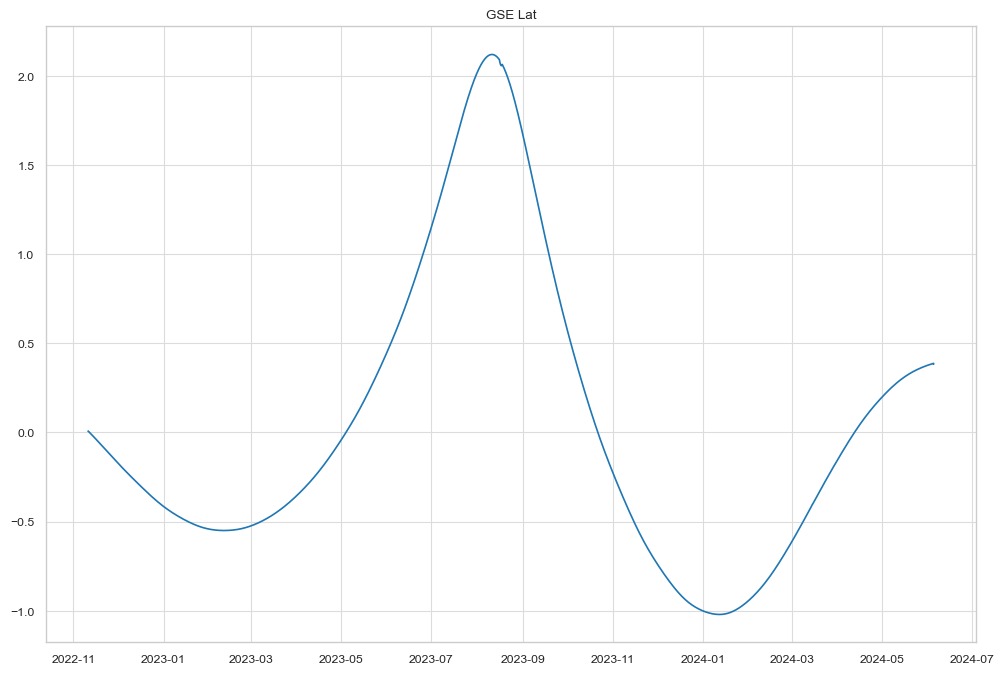

In [87]:
plt.figure(1, figsize=(12,8))
plt.plot(sta_gse.time, sta_gse.x, color='tab:blue')
plt.title('GSE X')

plt.figure(2, figsize=(12,8))
plt.plot(sta_gse.time, sta_gse.y, color='tab:blue')
plt.title('GSE Y')

plt.figure(3, figsize=(12,8))
plt.plot(sta_gse.time, sta_gse.r, color='tab:blue')
plt.title('GSE R')

plt.figure(4, figsize=(12,8))
plt.plot(sta_gse.time, sta_gse.lon, color='tab:blue')
plt.title('GSE Lon')

plt.figure(5, figsize=(12,8))
plt.plot(sta_gse.time, sta_gse.lat, color='tab:blue')
plt.title('GSE Lat')

In [88]:
#save file:
pickle.dump(sc_mag_gsm, open(data_path+'sta_science_20221111_20240604_B_GSM_Coords_GSE_new.p', 'wb'))

### STEREO-A beacon data preparation

In [27]:
sta_input_beacon = pickle.load(open(data_path+'sta_beacon_20221101_20240606_gsm.p', 'rb')) 
print(sta_input_beacon.time[0], sta_input_beacon.time[-1])

2022-11-10 00:00:00 2024-06-06 00:00:00


In [28]:
sta_input_beacon_interp = interp_to_grid(sta_input_beacon)

2022-11-11 00:00:00 2024-06-05 00:00:00


In [29]:
sta_pos_df = pd.DataFrame(sta_input_beacon_interp[['time', 'x', 'y', 'z']].copy())
#sta_pos_df.x = sta_pos_df.x*u.au.to(u.km)
#sta_pos_df.y = sta_pos_df.y*u.au.to(u.km)
#sta_pos_df.z = sta_pos_df.z*u.au.to(u.km)

#print(l1_df) # check if x,y,z are given in km or au

sta_pos_hee = HEEQ_to_HEE(sta_pos_df)
sta_pos_gse = HEE_to_GSE(sta_pos_hee)


In [30]:
sta_fin_beacon = copy.deepcopy(sta_input_beacon_interp)

sta_fin_beacon.x = sta_pos_gse.x
sta_fin_beacon.y = sta_pos_gse.y
sta_fin_beacon.z = sta_pos_gse.z
sta_fin_beacon.r = sta_pos_gse.r
sta_fin_beacon.lon = sta_pos_gse.lon
sta_fin_beacon.lat = sta_pos_gse.lat

sta_fin_beacon = sta_fin_beacon[(sta_fin_beacon.time>=datetime(2022,11,11)) & (sta_fin_beacon.time<=datetime(2024,6,5))]
print(sta_fin_beacon)

[(datetime.datetime(2022, 11, 11, 0, 0),  2.9055214 , -11.40385707,  -0.4279499 , 11.82987976, 0.25824129, 0.00744495,  76.12375802,  9265022.3518835 ,  37504901.29744815,   5019.84312978, 0., 0., 0.,          nan, nan,         nan)
 (datetime.datetime(2022, 11, 11, 0, 1),  1.39879183, -10.33250055,  -3.03777946, 11.58671093, 0.25824078, 0.00743902,  76.12381102,  9264969.21439841,  37504835.20704112,   5015.83662987, 0., 0., 0., 586.94622132, nan, 15.65718143)
 (datetime.datetime(2022, 11, 11, 0, 2), -3.62879907,  -5.52124879, -10.03207289, 12.05239201, 0.25824027, 0.00743309,  76.12386402,  9264916.07737577,  37504769.1174742 ,   5011.83012688, 0., 0., 0.,          nan, nan,         nan)
 ...
 (datetime.datetime(2024, 6, 4, 23, 58), -4.99778264,   6.20476158,  -1.71515001,  8.23475933, 0.26485974, 0.38776551, -69.53731616, 13851584.02449647, -37121429.57618422, 268154.19710371, 0., 0., 0.,          nan, nan,         nan)
 (datetime.datetime(2024, 6, 4, 23, 59), -4.75412517,   5.98108

In [31]:
#save file:

pickle.dump(sta_fin_beacon, open(data_path+'sta_beacon_20221111_20240604_B_GSM_Coords_GSE_new.p', 'wb'))

Text(0.5, 1.0, 'GSE Lat')

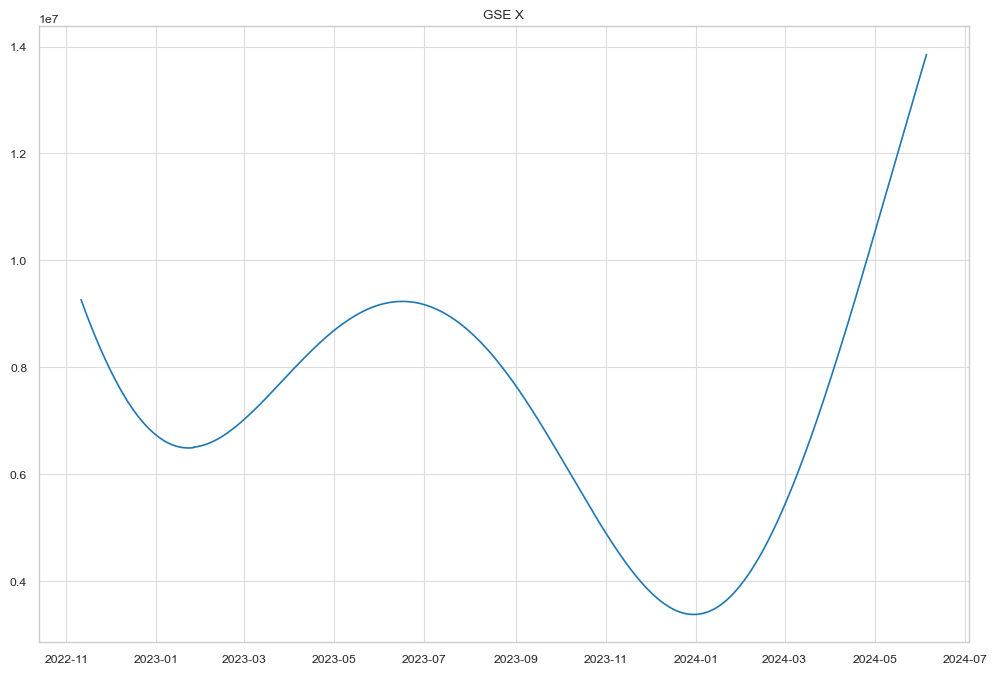

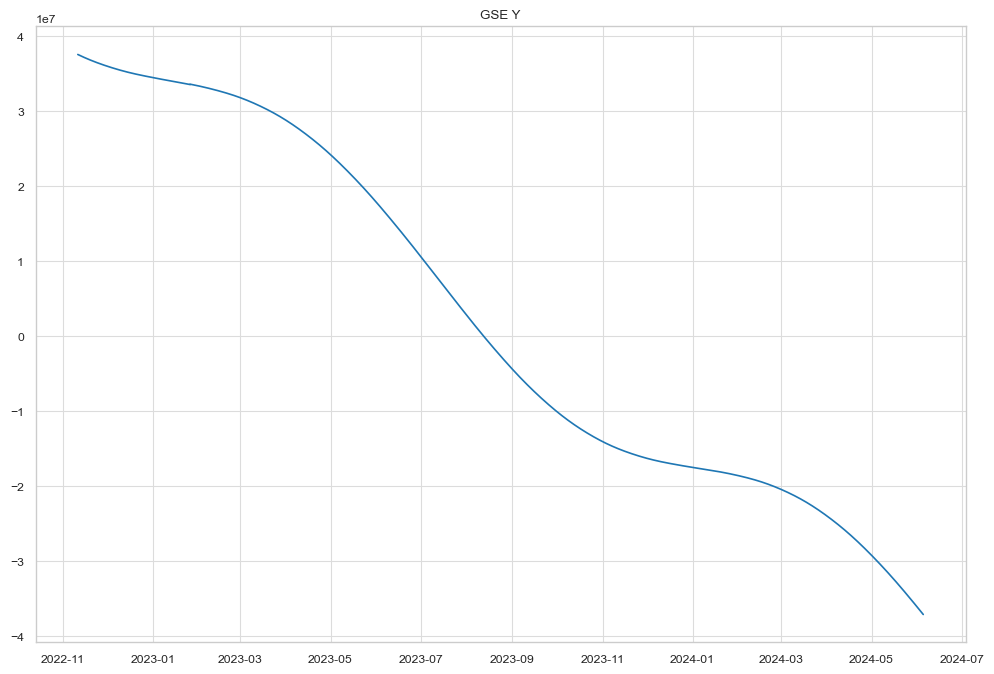

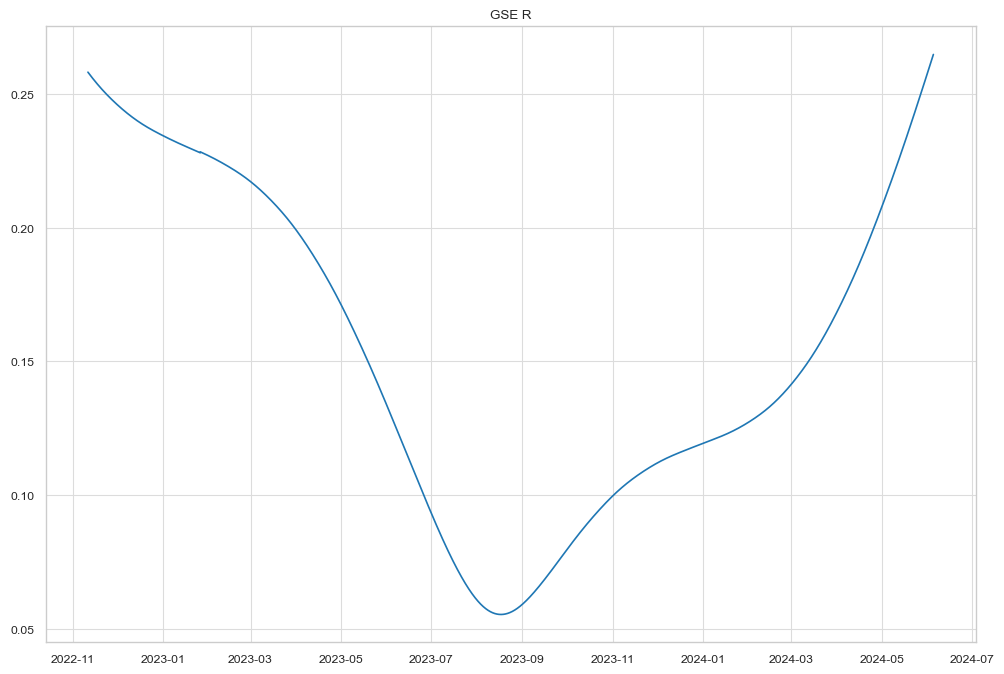

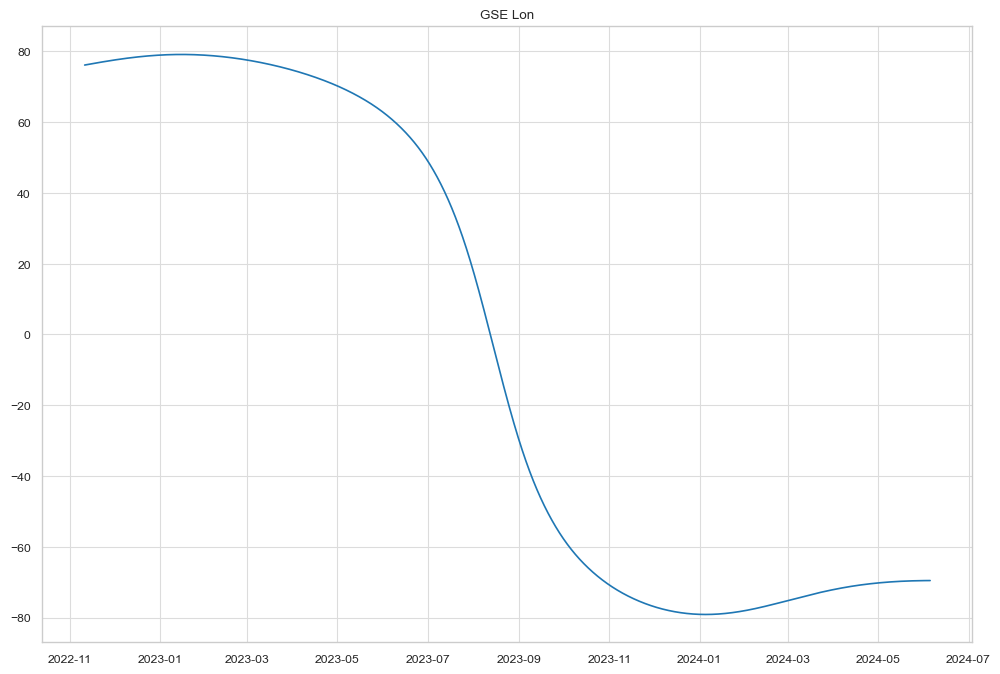

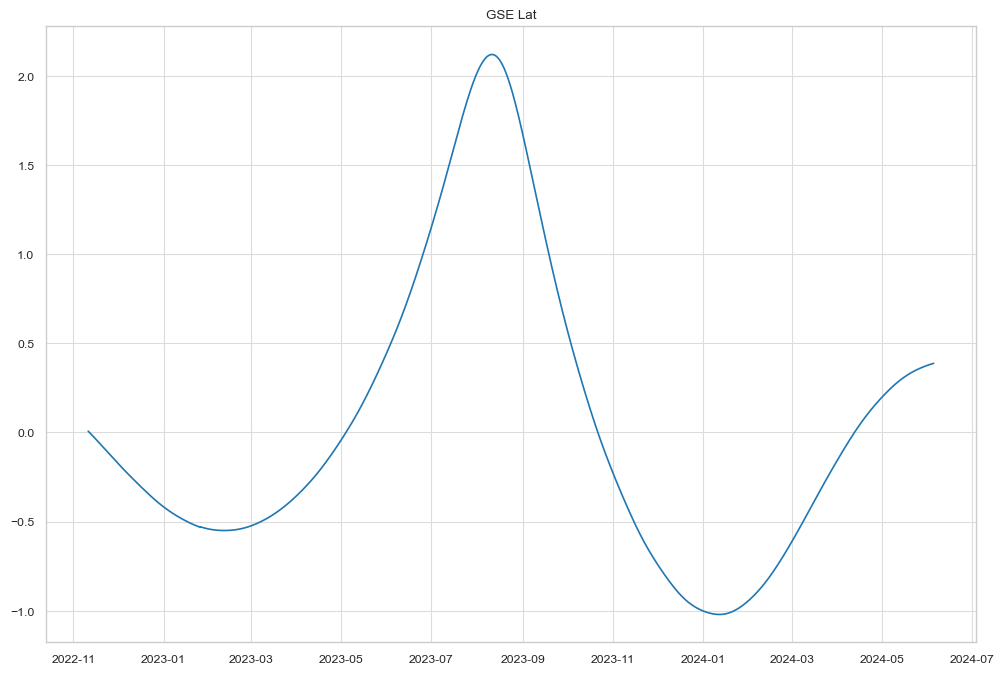

In [32]:
plt.figure(1, figsize=(12,8))
plt.plot(sta_fin_beacon.time, sta_fin_beacon.x, color='tab:blue')
#plt.plot(sta_gse_orig.time, sta_gse_orig.x, color='tab:orange')
plt.title('GSE X')

plt.figure(2, figsize=(12,8))
plt.plot(sta_fin_beacon.time, sta_fin_beacon.y, color='tab:blue')
#plt.plot(sta_gse_orig.time, sta_gse_orig.y, color='tab:orange')
plt.title('GSE Y')

plt.figure(3, figsize=(12,8))
plt.plot(sta_fin_beacon.time, sta_fin_beacon.r, color='tab:blue')
#plt.plot(sta_gse_orig.time, sta_gse_orig.r, color='tab:orange')
plt.title('GSE R')

plt.figure(4, figsize=(12,8))
plt.plot(sta_fin_beacon.time, sta_fin_beacon.lon, color='tab:blue')
#plt.plot(sta_gse_orig.time, sta_gse_orig.lon, color='tab:orange')
plt.title('GSE Lon')

plt.figure(5, figsize=(12,8))
plt.plot(sta_fin_beacon.time, sta_fin_beacon.lat, color='tab:blue')
#plt.plot(sta_gse_orig.time, sta_gse_orig.lat, color='tab:orange')
plt.title('GSE Lat')

## Get coordinates for Lagrangian points

In [22]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, timezone
from spacepy import pycdf
import cdflib
import spiceypy
import glob
import urllib.request
import os.path
import pickle


"""
LAGRANGE POINT functions: positions of L1, L2, L4 and L4 from generic and specific lagrange spice kernels
info: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/lagrange_point/AAREADME_Lagrange_point_SPKs.txt
L1: 391, L2: 392, L4: 394, L5: 395
"""


kernels_path=data_path+'kernels/'


def cart2sphere(x,y,z):
    r = np.sqrt(x**2+ y**2 + z**2) /1.495978707E8         
    theta = np.arctan2(z,np.sqrt(x**2+ y**2)) * 360 / 2 / np.pi
    phi = np.arctan2(y,x) * 360 / 2 / np.pi                   
    return (r, theta, phi)

"""
FURNISH KERNELS
https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/lagrange_point/
"""


def lagrange_furnish():
    """Main"""
    lagrange_path = kernels_path
    generic_path = kernels_path
    lagrange_kernels = os.listdir(lagrange_path)
    generic_kernels = os.listdir(generic_path)
    for kernel in lagrange_kernels:
        spiceypy.furnsh(os.path.join(lagrange_path, kernel))
    for kernel in generic_kernels:
        spiceypy.furnsh(os.path.join(generic_path, kernel))


def get_lagrange_pos(t, lagrange_point): #doesn't automatically furnish, furnish first
    if lagrange_point == "L1":
        lagrange_code = "391"
    elif lagrange_point == "L2":
        lagrange_code = "392"
    elif lagrange_point == "L3":
        print("L3 position calculation is unavailable")
        return
    elif lagrange_point == "L4":
        lagrange_code = "394"
    elif lagrange_point == "L5":
        lagrange_code = "395"
    try:
        pos = spiceypy.spkpos(lagrange_code, spiceypy.datetime2et(t), "HEEQ", "NONE", "SUN")[0] #calls positions in HEEQ; can be changed
        r, lat, lon = cart2sphere(pos[0],pos[1],pos[2])
        position = t, pos[0], pos[1], pos[2], r, lat, lon
        return position
    except Exception as e:
        print(e)
        return [t, None, None, None, None, None, None]


def get_lagrange_positions_daily(start, end, lagrange_point, cadence, dist_unit='au', ang_unit='deg'):
    t = start
    positions = []
    while t < end:
        position = get_lagrange_pos(t, lagrange_point)
        positions.append(position)
        t += timedelta(days=cadence)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    if dist_unit == 'au':
        df_positions.x = df_positions.x/1.495978707E8 
        df_positions.y = df_positions.y/1.495978707E8
        df_positions.z = df_positions.z/1.495978707E8
    if ang_unit == 'rad':
        df_positions.lat = df_positions.lat * np.pi / 180
        df_positions.lon = df_positions.lon * np.pi / 180
    spiceypy.kclear()
    return df_positions


def get_lagrange_positions_hourly(start, end, lagrange_point, cadence, dist_unit='au', ang_unit='deg'):
    t = start
    positions = []
    while t < end:
        position = get_lagrange_pos(t, lagrange_point)
        positions.append(position)
        t += timedelta(hours=cadence)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    if dist_unit == 'au':
        df_positions.x = df_positions.x/1.495978707E8 
        df_positions.y = df_positions.y/1.495978707E8
        df_positions.z = df_positions.z/1.495978707E8
    if ang_unit == 'rad':
        df_positions.lat = df_positions.lat * np.pi / 180
        df_positions.lon = df_positions.lon * np.pi / 180
    spiceypy.kclear()
    return df_positions


def get_lagrange_positions_minute(start, end, lagrange_point, cadence, dist_unit='au', ang_unit='deg'):
    t = start
    positions = []
    while t < end:
        position = get_lagrange_pos(t, lagrange_point)
        positions.append(position)
        t += timedelta(minutes=cadence)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    if dist_unit == 'au':
        df_positions.x = df_positions.x/1.495978707E8 
        df_positions.y = df_positions.y/1.495978707E8
        df_positions.z = df_positions.z/1.495978707E8
    if ang_unit == 'rad':
        df_positions.lat = df_positions.lat * np.pi / 180
        df_positions.lon = df_positions.lon * np.pi / 180
    spiceypy.kclear()
    return df_positions

In [31]:
lagrange_furnish()
l1_pos = get_lagrange_positions_minute(datetime(2022,11,11), datetime(2024,6,5,0,1), 'L1', 1)

[1.46320522e+08 1.46320510e+08 1.46320497e+08 ... 1.50320302e+08
 1.50320315e+08 1.50320328e+08]


In [33]:


#pickle.dump(l1_pos, open(data_path+'l1_pos_20221111_20240604.p', 'wb'))